# PTID-CDS-DEC-25-3624_PRCP-1004-Fifa20

In [1]:
# import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# configurations
import warnings
warnings.filterwarnings("ignore")

# seaborn plot style
sns.set(style="whitegrid")

## Data analysis

In [3]:
# load dataset
url = 'datasets/players_20.csv'  # Update with the correct path
data = pd.read_csv(url)

In [4]:
# show first 5 rows
print("First five rows of the dataset:")
print(data.head())

First five rows of the dataset:
   sofifa_id                                         player_url  \
0     158023  https://sofifa.com/player/158023/lionel-messi/...   
1      20801  https://sofifa.com/player/20801/c-ronaldo-dos-...   
2     190871  https://sofifa.com/player/190871/neymar-da-sil...   
3     200389  https://sofifa.com/player/200389/jan-oblak/20/...   
4     183277  https://sofifa.com/player/183277/eden-hazard/2...   

          short_name                            long_name  age         dob  \
0           L. Messi       Lionel Andrés Messi Cuccittini   32  1987-06-24   
1  Cristiano Ronaldo  Cristiano Ronaldo dos Santos Aveiro   34  1985-02-05   
2          Neymar Jr        Neymar da Silva Santos Junior   27  1992-02-05   
3           J. Oblak                            Jan Oblak   26  1993-01-07   
4          E. Hazard                          Eden Hazard   28  1991-01-07   

   height_cm  weight_kg nationality                 club  ...   lwb   ldm  \
0        170       

In [5]:
# dataset basic info
print("\nDataset information:")
print(data.info())


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18278 entries, 0 to 18277
Columns: 104 entries, sofifa_id to rb
dtypes: float64(16), int64(45), object(43)
memory usage: 14.5+ MB
None


In [6]:
# show summary stats
print("\nSummary statistics:")
print(data.describe())


Summary statistics:
           sofifa_id           age     height_cm     weight_kg       overall  \
count   18278.000000  18278.000000  18278.000000  18278.000000  18278.000000   
mean   219738.864482     25.283291    181.362184     75.276343     66.244994   
std     27960.200461      4.656964      6.756961      7.047744      6.949953   
min       768.000000     16.000000    156.000000     50.000000     48.000000   
25%    204445.500000     22.000000    177.000000     70.000000     62.000000   
50%    226165.000000     25.000000    181.000000     75.000000     66.000000   
75%    240795.750000     29.000000    186.000000     80.000000     71.000000   
max    252905.000000     42.000000    205.000000    110.000000     94.000000   

          potential     value_eur       wage_eur  international_reputation  \
count  18278.000000  1.827800e+04   18278.000000              18278.000000   
mean      71.546887  2.484038e+06    9456.942773                  1.103184   
std        6.139669  5.5

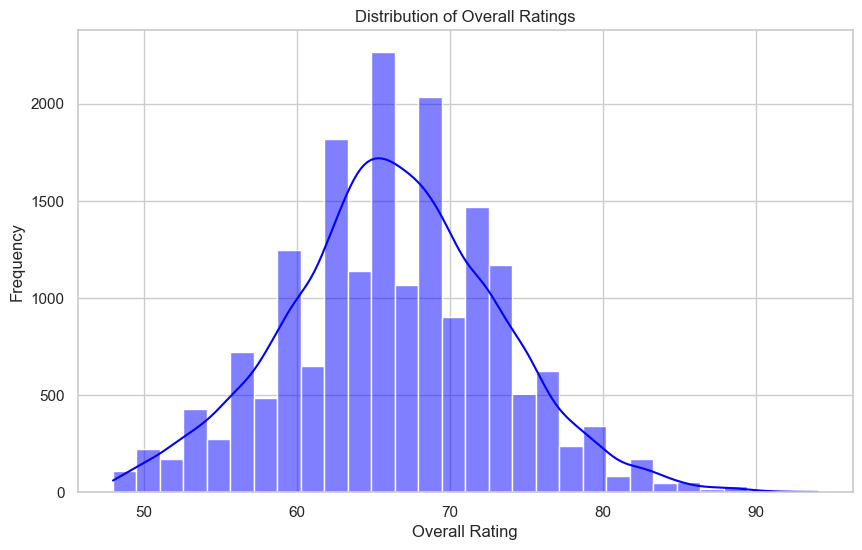

In [7]:
# overall ratings distribution
plt.figure(figsize=(10, 6))
sns.histplot(data['overall'], bins=30, color='blue', kde=True)
plt.title('Distribution of Overall Ratings')
plt.xlabel('Overall Rating')
plt.ylabel('Frequency')
plt.show()

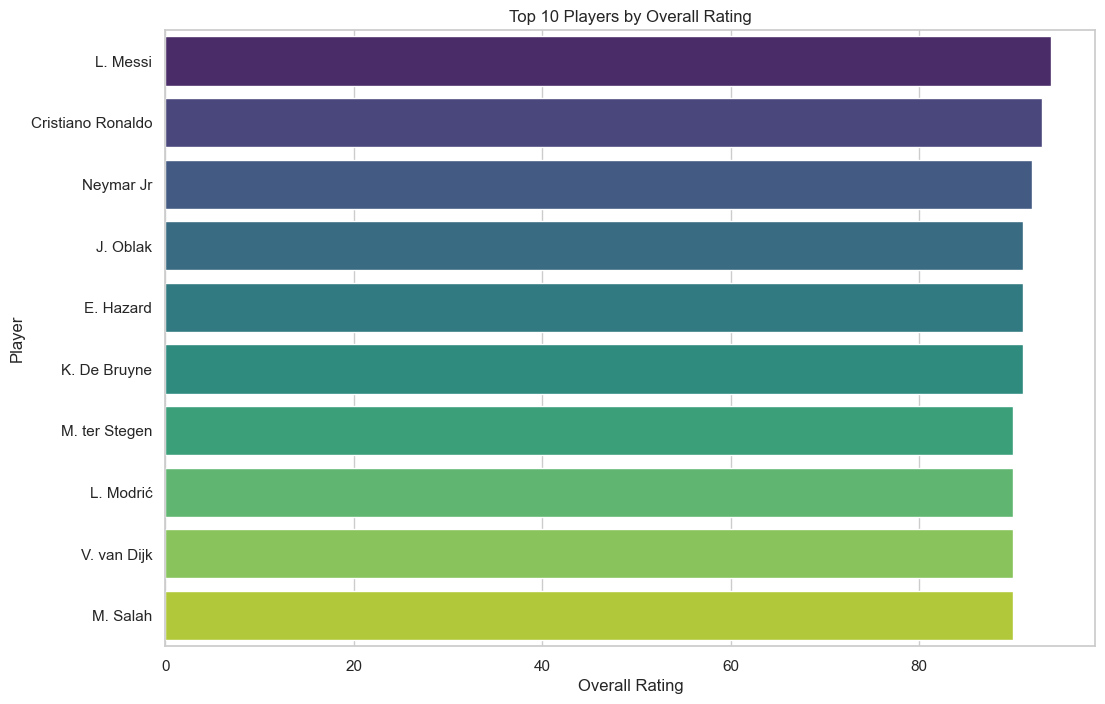

In [8]:
# top 10 players by overall ratings
top_players = data.sort_values(by='overall', ascending=False).head(10)
plt.figure(figsize=(12, 8))
sns.barplot(x='overall', y='short_name', data=top_players, palette='viridis', hue=None, legend=False)
plt.title('Top 10 Players by Overall Rating')
plt.xlabel('Overall Rating')
plt.ylabel('Player')
plt.show()

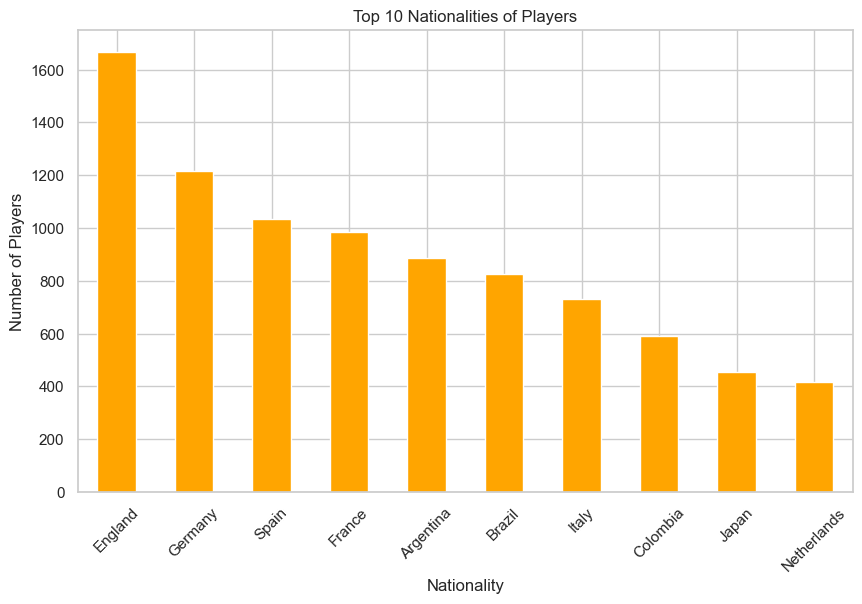

In [9]:
# top 10 players by nationality
top_nationalities = data['nationality'].value_counts().head(10)
plt.figure(figsize=(10, 6))
top_nationalities.plot(kind='bar', color='orange')
plt.title('Top 10 Nationalities of Players')
plt.xlabel('Nationality')
plt.ylabel('Number of Players')
plt.xticks(rotation=45)
plt.show()

<Figure size 1200x1000 with 0 Axes>

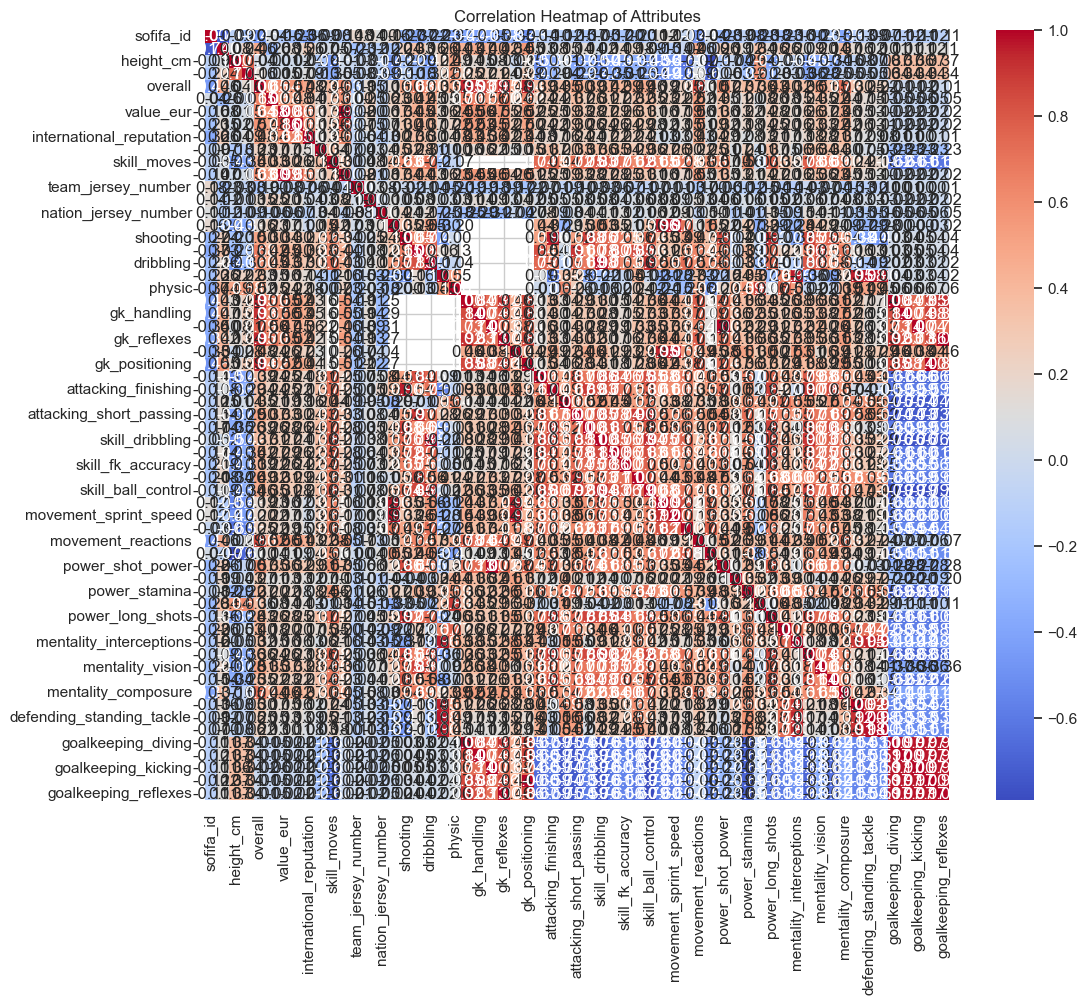

In [10]:
# heatmap - correlation of numerical attr
numeric_data = data.select_dtypes(include=[np.number])
plt.figure(figsize=(12, 10))
correlation_matrix = numeric_data.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Heatmap of Attributes')
plt.show()

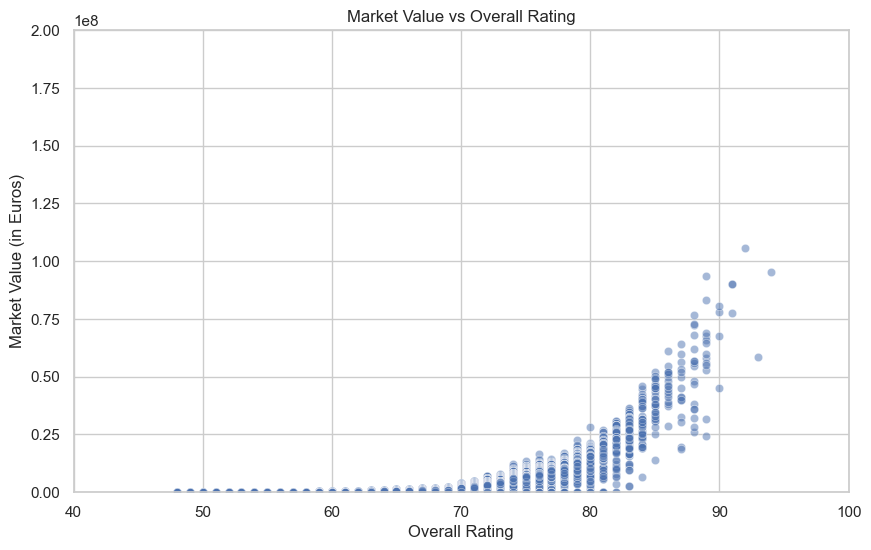

In [11]:
# market value vs overall rating
plt.figure(figsize=(10, 6))
sns.scatterplot(x='overall', y='value_eur', data=data, alpha=0.5)
plt.title('Market Value vs Overall Rating')
plt.xlabel('Overall Rating')
plt.ylabel('Market Value (in Euros)')
plt.xlim(40, 100)
plt.ylim(0, 200000000)
plt.show()

## Clustering

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [13]:
# EDA on key football skills
attributes = ['pace', 'shooting', 'passing', 'dribbling', 'defending', 'overall']
cdata = data[attributes].copy()

In [14]:
# check missing values
print(cdata.isnull().sum())

pace         2036
shooting     2036
passing      2036
dribbling    2036
defending    2036
overall         0
dtype: int64


In [15]:
# fill missing values with mean val
cdata.fillna(cdata.mean(), inplace=True)

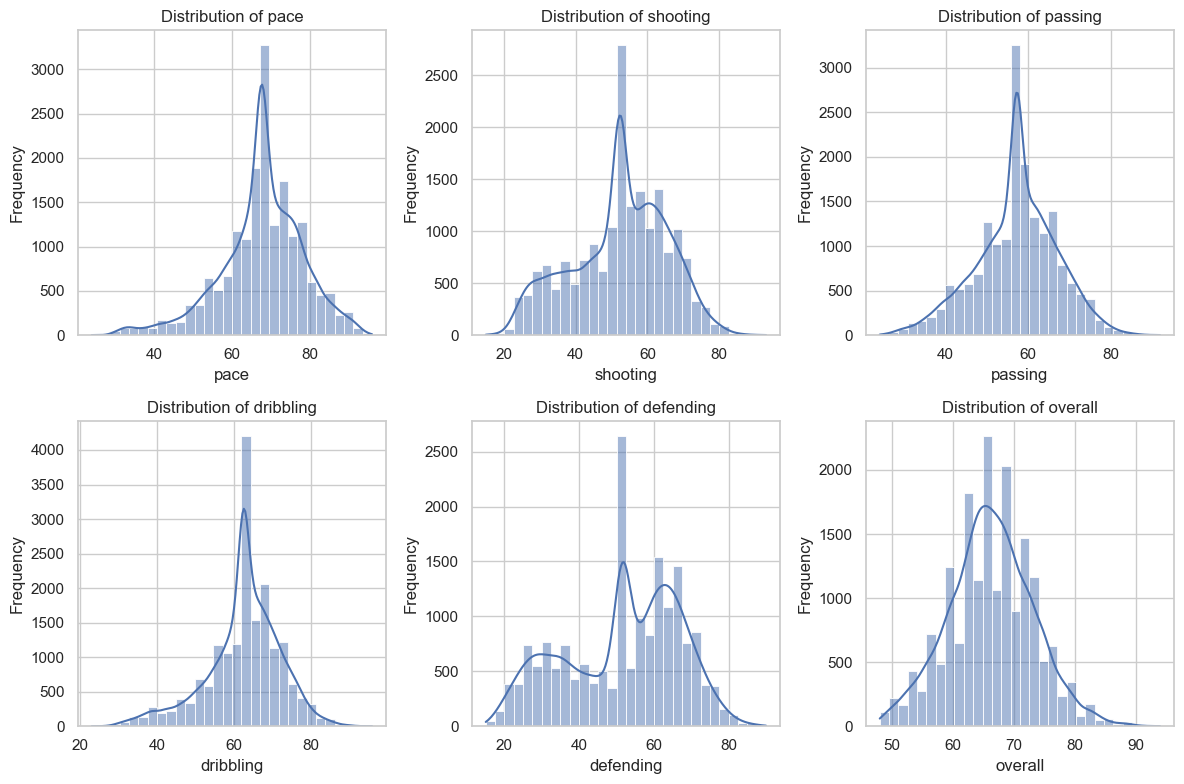

In [16]:
# skill distributions plot
plt.figure(figsize=(12, 8))
for i, column in enumerate(cdata.columns, 1):
    plt.subplot(2, 3, i)
    sns.histplot(cdata[column], bins=30, kde=True)
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [17]:
# normalize data
scaler = StandardScaler()
cdata_scaled = scaler.fit_transform(cdata)

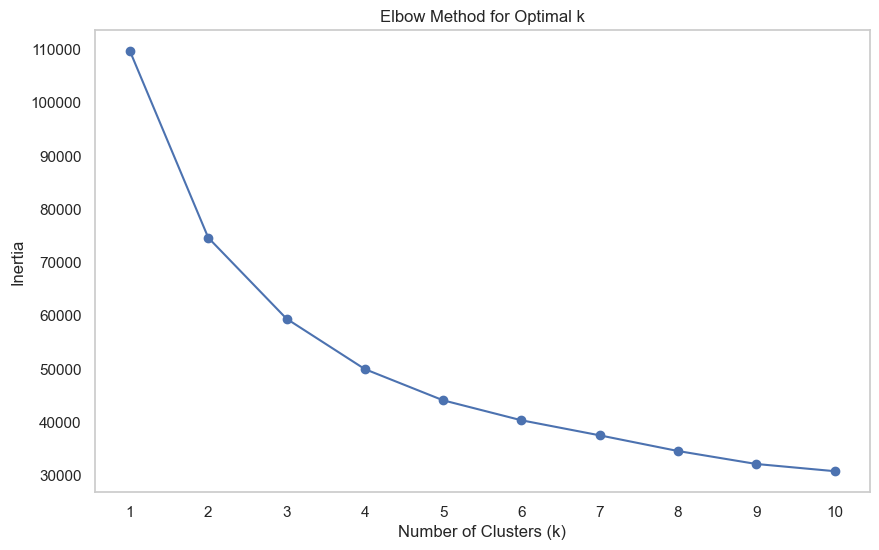

In [18]:
# k means clustering
inertia = []
ck_values = range(1, 11)
for ck in ck_values:
    kmeans = KMeans(n_clusters=ck, random_state=42)
    kmeans.fit(cdata_scaled)
    inertia.append(kmeans.inertia_)

# elbow method plot
plt.figure(figsize=(10, 6))
plt.plot(ck_values, inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(ck_values)
plt.grid()
plt.show()

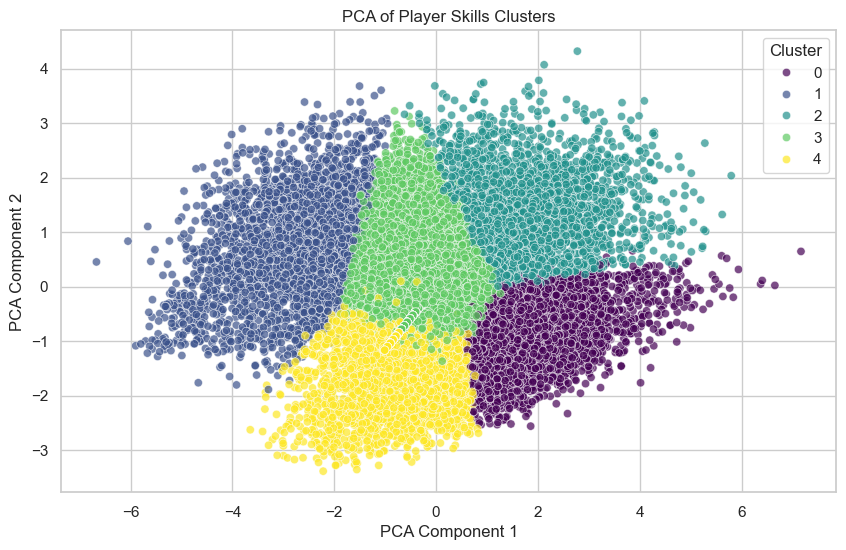

In [19]:
# Assume optimal k to be 5
optimal_ck = 5
kmeans = KMeans(n_clusters=optimal_ck, random_state=42)
clusters = kmeans.fit_predict(cdata_scaled)

# add cluster info to the original data
cdata['Cluster'] = clusters

# plot clusters using PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(cdata_scaled)
cdata['PCA1'] = pca_result[:, 0]
cdata['PCA2'] = pca_result[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=cdata, palette='viridis', alpha=0.7)
plt.title('PCA of Player Skills Clusters')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster')
plt.show()

In [20]:
# show cluster centers in original space
cluster_centers = scaler.inverse_transform(kmeans.cluster_centers_)
cluster_centers_data = pd.DataFrame(data=cluster_centers, columns=attributes)

# show cluster centers with player attributes
print(cluster_centers_data)

        pace   shooting    passing  dribbling  defending    overall
0  76.747233  66.394556  63.209692  71.772360  35.532755  70.523781
1  56.492063  32.098765  43.940035  46.556261  61.857848  62.855379
2  68.562891  61.428401  69.370889  71.316468  66.629050  74.307275
3  67.347236  48.704932  58.031218  62.193208  57.938192  65.228286
4  68.187051  55.020499  50.072846  59.896670  31.630725  59.251026


## top 10 countries with most players

In [21]:
# count players by country
country_counts = data['nationality'].value_counts()

# get top 10 countries
top_countries = country_counts.head(10)

# print top 10 countries
print(top_countries)

nationality
England        1667
Germany        1216
Spain          1035
France          984
Argentina       886
Brazil          824
Italy           732
Colombia        591
Japan           453
Netherlands     416
Name: count, dtype: int64


## overall rating vs. age of players

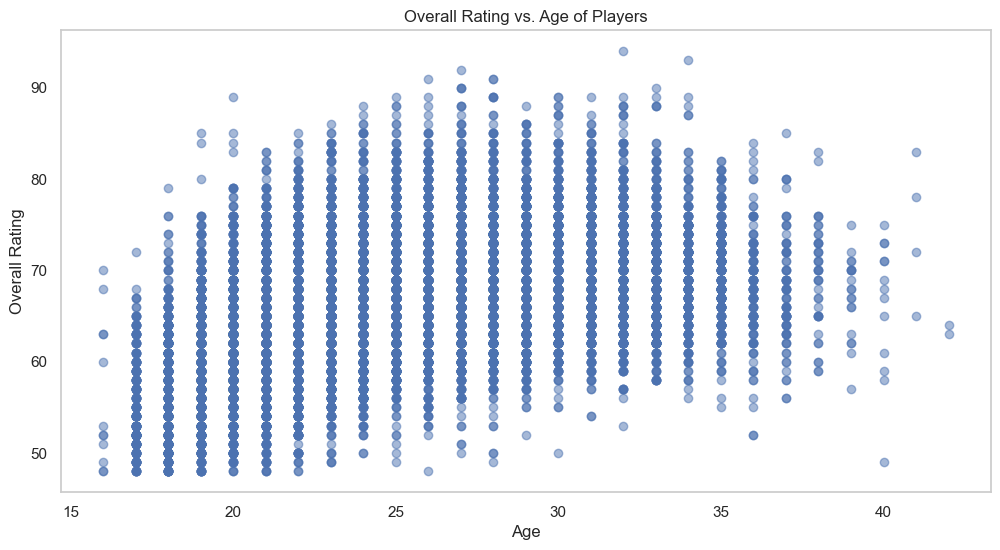

In [22]:
# sselecting req columns
age = data['age']
overall_rating = data['overall']

# create scatter plot
plt.figure(figsize=(12, 6))
plt.scatter(age, overall_rating, alpha=0.5)
plt.title('Overall Rating vs. Age of Players')
plt.xlabel('Age')
plt.ylabel('Overall Rating')
plt.grid()
plt.show()

## age after which a player stops improving

In [23]:
# select req columns
# drop na values
nidata = data[['age', 'overall', 'potential']]
nidata = nidata.dropna()

# group by age
# calculate the average overall and potential
age_grouped = nidata.groupby('age').mean().reset_index()

# add new column
# check if a player is improving
age_grouped['improvement'] = age_grouped['potential'] - age_grouped['overall']

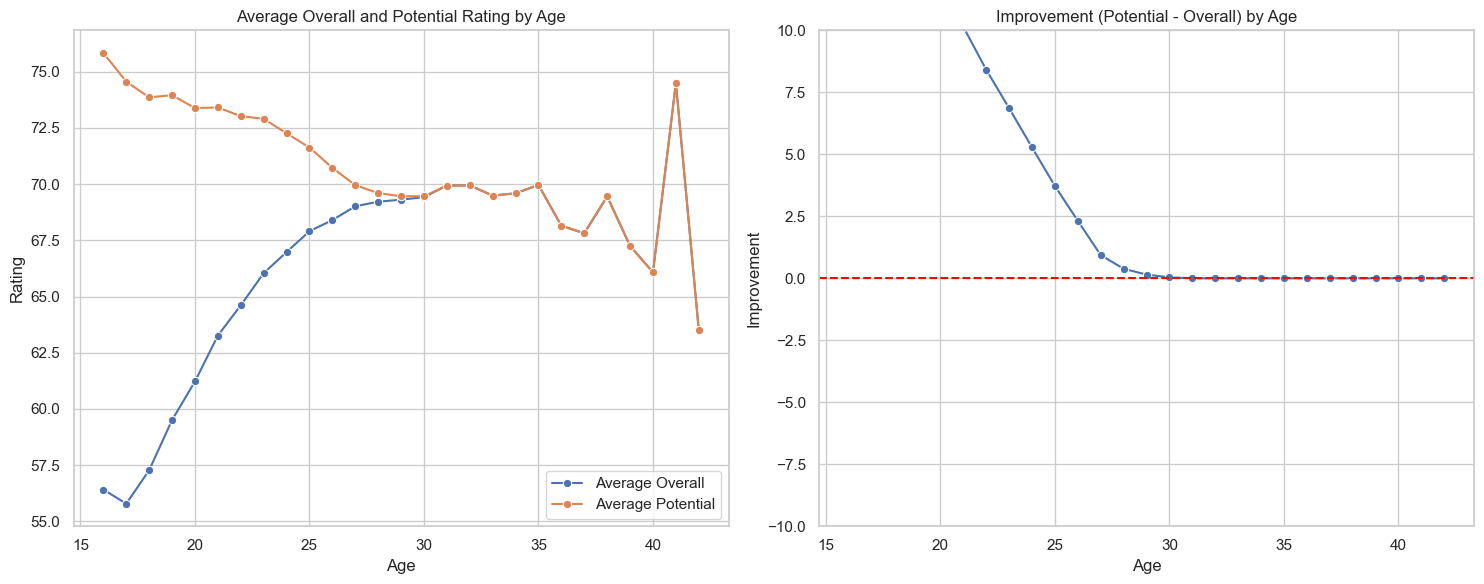

In [24]:
# plot average overall rating and potential by age
plt.figure(figsize=(15, 6))

# plot overall vs age
plt.subplot(1, 2, 1)
sns.lineplot(x='age', y='overall', data=age_grouped, marker='o', label='Average Overall')
sns.lineplot(x='age', y='potential', data=age_grouped, marker='o', label='Average Potential')
plt.title('Average Overall and Potential Rating by Age')
plt.xlabel('Age')
plt.ylabel('Rating')
plt.legend()

# plot improvement vs age
plt.subplot(1, 2, 2)
sns.lineplot(x='age', y='improvement', data=age_grouped, marker='o')
plt.axhline(0, color='red', linestyle='--')
plt.title('Improvement (Potential - Overall) by Age')
plt.xlabel('Age')
plt.ylabel('Improvement')
plt.ylim(-10, 10)

plt.tight_layout()
plt.show()

In [25]:
# check improvement values
print(age_grouped[['age', 'overall', 'potential', 'improvement']])

# check where players stop showing significant improvement
# set threshold for min improvement
threshold = 1

# find first occurence in age where improvement is no longer above threshold val
if not age_grouped[age_grouped['improvement'] < threshold].empty:
    age_stopping_improvement = age_grouped[age_grouped['improvement'] < threshold].age.min()
    print(f"Players typically stop showing significant improvement (less than set threshold {threshold}) at age {age_stopping_improvement}.")
else:
    print("Players continue to improve or unable to determine where improvement stops due to insufficient data points.")

    age    overall  potential  improvement
0    16  56.416667  75.833333    19.416667
1    17  55.786026  74.558952    18.772926
2    18  57.273438  73.859375    16.585938
3    19  59.507418  73.954500    14.447082
4    20  61.222133  73.382518    12.160385
5    21  63.262545  73.408000    10.145455
6    22  64.609959  73.024896     8.414938
7    23  66.038292  72.902798     6.864507
8    24  66.977623  72.260031     5.282407
9    25  67.904473  71.627748     3.723275
10   26  68.400787  70.722835     2.322047
11   27  69.013595  69.949396     0.935801
12   28  69.216390  69.603131     0.386740
13   29  69.308308  69.458458     0.150150
14   30  69.420159  69.460929     0.040770
15   31  69.938042  69.938042     0.000000
16   32  69.941374  69.941374     0.000000
17   33  69.488421  69.488421     0.000000
18   34  69.591362  69.591362     0.000000
19   35  69.961290  69.961290     0.000000
20   36  68.145038  68.145038     0.000000
21   37  67.814815  67.814815     0.000000
22   38  69

## type of offensive players tends to get paid the most

In [26]:
opdata = data.copy()

# split player_positions into a list
opdata['player_positions'] = opdata['player_positions'].str.split(',')

In [27]:
# define function to categorize players into offensive types
def categorize_offensive_player(positions):
    if any(pos in positions for pos in ['ST', 'CF', 'LS', 'RS']):
        return 'Striker'
    elif any(pos in positions for pos in ['RW']):
        return 'Right Winger'
    elif any(pos in positions for pos in ['LW']):
        return 'Left Winger'
    else:
        return None

In [28]:
# apply function to create a new column for player type
opdata['offensive_type'] = opdata['player_positions'].apply(categorize_offensive_player)

# filter out rows where offensive_type is none
offensive_players = opdata[opdata['offensive_type'].notnull()]

# group by offensive type and calculate average wage
avg_wage_by_type = offensive_players.groupby('offensive_type')['wage_eur'].mean().reset_index()

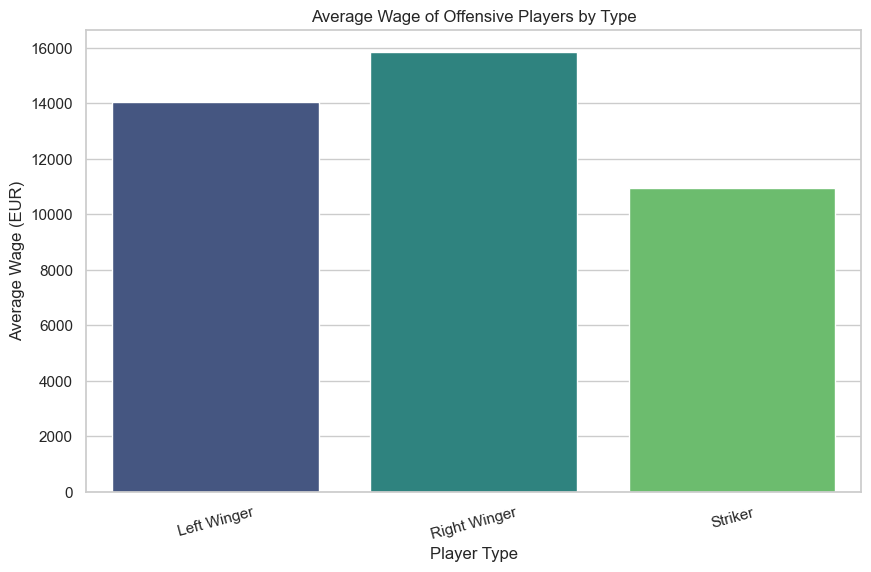

In [29]:
# plotting the average wages
plt.figure(figsize=(10, 6))
sns.barplot(x='offensive_type', y='wage_eur', data=avg_wage_by_type, palette='viridis')
plt.title('Average Wage of Offensive Players by Type')
plt.ylabel('Average Wage (EUR)')
plt.xlabel('Player Type')
plt.xticks(rotation=15)
plt.show()

In [30]:
# print average wages for offensive players by type
for index, row in avg_wage_by_type.iterrows():
    print(f"The average wage for {row['offensive_type']} is {row['wage_eur']:,.0f} EUR.")

The average wage for Left Winger is 14,037 EUR.
The average wage for Right Winger is 15,848 EUR.
The average wage for Striker is 10,928 EUR.
